In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================
import os
import re
import ast
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

# Sastrawi
!pip install -q Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Tensorflow
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    SpatialDropout1D,
    BatchNormalization
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight

# Imbalance
!pip install -q imbalanced-learn
from imblearn.over_sampling import RandomOverSampler

# Transformer
!pip install -q transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.9 MB/s eta 0:00:00


Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================================
# PATH DATASET
# ==========================================================

DRIVE_PATH = "/content/drive/MyDrive/SKRIPSI_Yeni"

IG_PATH = f"{DRIVE_PATH}/hasil_ig_comments.csv"
X_PATH = f"{DRIVE_PATH}/hasil_x_comments.csv"

OUTPUT_PATH = f"{DRIVE_PATH}/hasil_scraping_comments_mbg.csv"

os.makedirs(DRIVE_PATH, exist_ok=True)

Load Dataset

In [4]:
# ==========================================================
# LOAD DATASET
# ==========================================================

df_ig = pd.read_csv(IG_PATH)
df_x = pd.read_csv(X_PATH)

print("Jumlah komentar Instagram :", len(df_ig))
print("Jumlah komentar X :", len(df_x))

Jumlah komentar Instagram : 2300
Jumlah komentar X : 2087


Gabungkan Dataset

In [5]:
# ==========================================================
# GABUNG DATASET
# ==========================================================

df = pd.concat(
    [df_ig, df_x],
    ignore_index=True
)

df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding='utf-8-sig'
)

print("Jumlah data gabungan :",len(df))

display(df.head())

Jumlah data gabungan : 4387


,id,text,createdAt,createdAtISO,likes,childCommentCount,parentCommentId,hasTranslation,hasLikedComment,isCovered,...,created_at,retweets,replies,quotes,views,author_id,author_username,author_name,author_followers,author_verified
0,1.807433e+16,Kerjaan guru jauh lebih mulia dibandingkan pek...,1.769008e+09,2026-01-21T15:12:12.000Z,106,12.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.808680e+16,Yg salah bukan pegawainya sih. Yg salah ya PEM...,1.769051e+09,2026-01-22T03:04:07.000Z,9,0.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.790481e+16,Pada happy happy ya. . .,1.769048e+09,2026-01-22T02:10:12.000Z,3,8.0,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.810844e+16,Gue senang melihat orang bisa mendapatkan peke...,1.769106e+09,2026-01-22T18:25:55.000Z,1,0.0,NaN,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.812040e+16,Semangat 💪🔥,1.769053e+09,2026-01-22T03:30:50.000Z,2,0.0,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cek struktur data

In [6]:
print(df.info())

print(df.isnull().sum())

display(df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4387 entries, 0 to 4386
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2300 non-null   float64
 1   text               4305 non-null   object 
 2   createdAt          2300 non-null   float64
 3   createdAtISO       2300 non-null   object 
 4   likes              4387 non-null   int64  
 5   childCommentCount  2300 non-null   float64
 6   parentCommentId    0 non-null      float64
 7   hasTranslation     2300 non-null   object 
 8   hasLikedComment    2300 non-null   object 
 9   isCovered          2300 non-null   object 
 10  restrictedStatus   0 non-null      float64
 11  typename           2300 non-null   object 
 12  giphyMediaInfo     81 non-null     object 
 13  author             2300 non-null   object 
 14  postUrl            2300 non-null   object 
 15  postShortcode      2300 non-null   object 
 16  post_url           2087 

,id,text,createdAt,createdAtISO,likes,childCommentCount,parentCommentId,hasTranslation,hasLikedComment,isCovered,...,created_at,retweets,replies,quotes,views,author_id,author_username,author_name,author_followers,author_verified
306,1.789114e+16,"Sudah dibilang, ini bukan program. Tapi proyek.",1.780970e+09,2026-06-09T01:49:47.000Z,343,0.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2485,NaN,sekarang malah nambah bikin univ. udah gatau l...,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,...,Fri Jul 24 11:54:29 +0000 2026,0.0,1.0,0.0,310.0,1.133899e+18,awaaannnn__,fin,11888.0,True
1501,1.795126e+16,Sehat guru dan tenaga kesehatan,1.780501e+09,2026-06-03T15:34:58.000Z,648,11.0,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1730,1.808272e+16,Udah muncul campaign agama ini loh @radenfajja...,1.784863e+09,2026-07-24T03:11:28.000Z,0,1.0,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3372,NaN,Mau ga mau naik lagi gr2 embeji https://t.co/k...,NaN,NaN,131,NaN,NaN,NaN,NaN,NaN,...,Sat Jul 11 02:04:29 +0000 2026,0.0,1.0,0.0,29974.0,1.644373e+18,DavidDailyBytes,David,2722.0,True


Preprocessing Data

1. Cleaning Data

In [7]:
# ==========================================================
# CLEANING
# ==========================================================

import re

my_df = df.copy()

# Ganti nama kolom text menjadi content
my_df.rename(columns={'text':'content'}, inplace=True)

print("Jumlah data awal :",len(my_df))

# Hapus missing value
my_df.dropna(subset=['content'], inplace=True)

# Hapus string kosong
my_df = my_df[my_df['content'].str.strip()!='']

# Hapus duplikat
before = len(my_df)
my_df.drop_duplicates(subset=['content'], inplace=True)

print("Duplikat dihapus :",before-len(my_df))

def clean_text(text):

    text = str(text)

    # URL
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Mention
    text = re.sub(r'@\w+', ' ', text)

    # Hashtag (#kata -> kata)
    text = re.sub(r'#', '', text)

    # Emoji & simbol
    text = re.sub(r'[^\w\s]', ' ', text)

    # Angka
    text = re.sub(r'\d+', ' ', text)

    # Spasi berlebih
    text = re.sub(r'\s+',' ',text)

    return text.strip()

my_df['content'] = my_df['content'].apply(clean_text)

# Hapus kosong setelah cleaning
my_df = my_df[my_df['content']!='']

print("Jumlah data setelah cleaning :",len(my_df))

display(my_df.head())

Jumlah data awal : 4387
Duplikat dihapus : 558
Jumlah data setelah cleaning : 3637


,id,content,createdAt,createdAtISO,likes,childCommentCount,parentCommentId,hasTranslation,hasLikedComment,isCovered,...,created_at,retweets,replies,quotes,views,author_id,author_username,author_name,author_followers,author_verified
0,1.807433e+16,Kerjaan guru jauh lebih mulia dibandingkan pek...,1.769008e+09,2026-01-21T15:12:12.000Z,106,12.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.808680e+16,Yg salah bukan pegawainya sih Yg salah ya PEME...,1.769051e+09,2026-01-22T03:04:07.000Z,9,0.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.790481e+16,Pada happy happy ya,1.769048e+09,2026-01-22T02:10:12.000Z,3,8.0,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.810844e+16,Gue senang melihat orang bisa mendapatkan peke...,1.769106e+09,2026-01-22T18:25:55.000Z,1,0.0,NaN,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.812040e+16,Semangat,1.769053e+09,2026-01-22T03:30:50.000Z,2,0.0,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2. Case Folding

In [8]:
# ==========================================================
# CASE FOLDING
# ==========================================================

my_df['text_clean'] = my_df['content'].str.lower()

display(
    my_df[
        ['content','text_clean']
    ].head()
)

,content,text_clean
0,Kerjaan guru jauh lebih mulia dibandingkan pek...,kerjaan guru jauh lebih mulia dibandingkan pek...
1,Yg salah bukan pegawainya sih Yg salah ya PEME...,yg salah bukan pegawainya sih yg salah ya peme...
2,Pada happy happy ya,pada happy happy ya
3,Gue senang melihat orang bisa mendapatkan peke...,gue senang melihat orang bisa mendapatkan peke...
4,Semangat,semangat


3. Normalisasi

In [9]:
# ==========================================================
# NORMALISASI
# ==========================================================

kamus_alay = {

'gk':'tidak',
'gak':'tidak',
'ga':'tidak',
'tdk':'tidak',
'yg':'yang',
'dgn':'dengan',
'dr':'dari',
'utk':'untuk',
'jd':'jadi',
'krn':'karena',
'karna':'karena',
'blm':'belum',
'udh':'sudah',
'udah':'sudah',
'jgn':'jangan',
'km':'kamu',
'kmu':'kamu',
'sy':'saya',
'org':'orang',
'bgt':'banget',
'tp':'tapi',
'jg':'juga',
'trs':'terus',
'byk':'banyak'
}

def normalize(text):
    words = text.split()
    hasil = []

    for word in words:
        hasil.append(
            kamus_alay.get(word,word)
        )
    return ' '.join(hasil)

my_df['text_normalized'] = my_df['text_clean'].apply(normalize)
display(

my_df[
['text_clean', 'text_normalized' ]
].head()

)

,text_clean,text_normalized
0,kerjaan guru jauh lebih mulia dibandingkan pek...,kerjaan guru jauh lebih mulia dibandingkan pek...
1,yg salah bukan pegawainya sih yg salah ya peme...,yang salah bukan pegawainya sih yang salah ya ...
2,pada happy happy ya,pada happy happy ya
3,gue senang melihat orang bisa mendapatkan peke...,gue senang melihat orang bisa mendapatkan peke...
4,semangat,semangat


4. Tokenizing

In [10]:
# ==========================================================
# TOKENIZING
# ==========================================================

nltk.download('punkt')
nltk.download('punkt_tab')

my_df['tokens'] = my_df['text_normalized'].apply(word_tokenize)
display(

my_df[
[ 'text_normalized', 'tokens' ]
].head()

)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text_normalized,tokens
0,kerjaan guru jauh lebih mulia dibandingkan pek...,"[kerjaan, guru, jauh, lebih, mulia, dibandingk..."
1,yang salah bukan pegawainya sih yang salah ya ...,"[yang, salah, bukan, pegawainya, sih, yang, sa..."
2,pada happy happy ya,"[pada, happy, happy, ya]"
3,gue senang melihat orang bisa mendapatkan peke...,"[gue, senang, melihat, orang, bisa, mendapatka..."
4,semangat,[semangat]


5. Stopwords Removal

In [11]:
# ==========================================================
# STOPWORD REMOVAL
# ==========================================================

stop_words = stopwords.words('indonesian')
keep_words = [
'tidak',
'bukan',
'belum',
'kurang',
'jangan',
'tak'
]

stop_words = [
w for w in stop_words
if w not in keep_words
]

my_df['tokens_stopword'] = my_df['tokens'].apply(lambda words:[
w
for w in words
if w not in stop_words])

display(
my_df[['tokens', 'tokens_stopword']].head()
)

,tokens,tokens_stopword
0,"[kerjaan, guru, jauh, lebih, mulia, dibandingk...","[kerjaan, guru, mulia, dibandingkan, pekerja, ..."
1,"[yang, salah, bukan, pegawainya, sih, yang, sa...","[salah, bukan, pegawainya, sih, salah, ya, pem..."
2,"[pada, happy, happy, ya]","[happy, happy, ya]"
3,"[gue, senang, melihat, orang, bisa, mendapatka...","[gue, senang, orang, pekerjaan, taiknya, pemer..."
4,[semangat],[semangat]


gabungan kalimat

In [12]:
# ==========================================================
# GABUNG TOKEN
# ==========================================================

my_df['text_final'] = my_df['tokens_stopword'].apply(
lambda x:' '.join(x))

display(
my_df[['text_normalized', 'text_final' ]
].head()
)

print("Jumlah data :",len(my_df))

,text_normalized,text_final
0,kerjaan guru jauh lebih mulia dibandingkan pek...,kerjaan guru mulia dibandingkan pekerja mbg ma...
1,yang salah bukan pegawainya sih yang salah ya ...,salah bukan pegawainya sih salah ya pemerintah...
2,pada happy happy ya,happy happy ya
3,gue senang melihat orang bisa mendapatkan peke...,gue senang orang pekerjaan taiknya pemerintah ...
4,semangat,semangat


Jumlah data : 3637


In [13]:
# ==========================================================
# SIMPAN HASIL PREPROCESSING
# ==========================================================

PREPROCESS_PATH = f"{DRIVE_PATH}/hasil_preprocessing.csv"
my_df.to_csv(PREPROCESS_PATH,index=False,encoding='utf-8-sig')

print("Preprocessing selesai.")
print("File disimpan di:")
print(PREPROCESS_PATH)

Preprocessing selesai.
File disimpan di:
/content/drive/MyDrive/SKRIPSI_Yeni/hasil_preprocessing.csv


Data Labeling

install library

In [14]:
!pip install -q transformers torch accelerate

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

data = pd.read_csv(f"{DRIVE_PATH}/hasil_preprocessing.csv")

MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"
device = 0 if torch.cuda.is_available() else -1
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device,
    truncation=True,
    max_length=128
)

config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

proses labelling

In [15]:
label_mapping = {
    "LABEL_0": "Positif",
    "LABEL_1": "Netral",
    "LABEL_2": "Negatif"
}

texts = data["text_normalized"].fillna("").astype(str).tolist()

labels = []
scores = []

print("Proses labelling...")

for result in sentiment_pipe(texts, batch_size=32):
    labels.append(label_mapping[result["label"]])
    scores.append(result["score"])

data["Label"] = labels
data["Confidence"] = scores

Proses labelling...


hasil labeling

In [16]:
print("Distribusi Label")
print(data["Label"].value_counts())

display(
    data[
        ["text_normalized","Label","Confidence"]
    ].head(10)
)

Distribusi Label
Label
Negatif    2478
Positif     696
Netral      463
Name: count, dtype: int64


,text_normalized,Label,Confidence
0,kerjaan guru jauh lebih mulia dibandingkan pek...,Positif,0.708786
1,yang salah bukan pegawainya sih yang salah ya ...,Negatif,0.997006
2,pada happy happy ya,Positif,0.970360
3,gue senang melihat orang bisa mendapatkan peke...,Negatif,0.983882
4,semangat,Positif,0.990639
5,nyewa buzzer yaah,Positif,0.928571
6,bahagianya liat kary mbg sehat selalu kawan be...,Positif,0.991949
7,min info loker,Netral,0.997425
8,bang elap nya tidak pernah di cucui ya ompreng...,Negatif,0.984442
9,semngat,Positif,0.991734


distribusi sentimen

Label
Negatif    2478
Netral      463
Positif     696
Name: count, dtype: int64


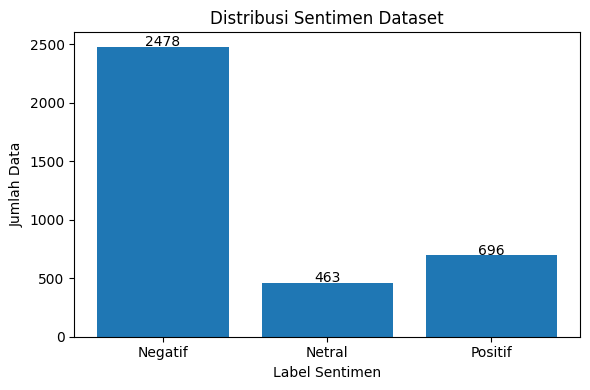

In [17]:
import matplotlib.pyplot as plt

label_order = ["Negatif", "Netral", "Positif"]

sentiment_counts = (
    data["Label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
)

print(sentiment_counts)

plt.figure(figsize=(6,4))

bars = plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Distribusi Sentimen Dataset")
plt.xlabel("Label Sentimen")
plt.ylabel("Jumlah Data")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha="center"
    )

plt.tight_layout()
plt.show()

simpan dataset

In [18]:
LABEL_PATH = f"{DRIVE_PATH}/dataset_labelled.csv"

data.to_csv(
    LABEL_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(f"Dataset berhasil disimpan di:\n{LABEL_PATH}")

Dataset berhasil disimpan di:
/content/drive/MyDrive/SKRIPSI_Yeni/dataset_labelled.csv


persiapan LSTM

Load Dataset & Label Encoding

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv(f"{DRIVE_PATH}/dataset_labelled.csv")

X = data["text_final"].fillna("")
y = data["Label"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Kelas Label :", list(label_encoder.classes_))
print("Jumlah Data :", len(X))

Kelas Label : ['Negatif', 'Netral', 'Positif']
Jumlah Data : 3637


Tokenizer & Padding

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = min(10000, len(set(" ".join(X).split())) + 1)
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(
    X_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Ukuran Data :", X_pad.shape)
print("Jumlah Vocabulary :", len(tokenizer.word_index))

Ukuran Data : (3637, 100)
Jumlah Vocabulary : 8043


Split Train, Validation, Test

In [21]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

X_temp, X_test, y_temp, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.15,
    random_state=42,
    stratify=y_temp
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"Train      : {len(X_train)}")
print(f"Validation : {len(X_val)}")
print(f"Test       : {len(X_test)}")

print("\nDistribusi Label Setelah SMOTE:")
print(pd.Series(y_train).value_counts())

Train      : 5052
Validation : 437
Test       : 728

Distribusi Label Setelah SMOTE:
0    1684
2    1684
1    1684
Name: count, dtype: int64


FastText Embedding

Install & Download FastText

In [22]:
!pip install -q fasttext

import os
import urllib.request
import gzip
import shutil
import fasttext

FASTTEXT_GZ = "cc.id.300.bin.gz"
FASTTEXT_BIN = "cc.id.300.bin"

if not os.path.exists(FASTTEXT_BIN):
    print("Mengunduh FastText Indonesia...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.bin.gz",
        FASTTEXT_GZ
    )

    print("Ekstraksi...")
    with gzip.open(FASTTEXT_GZ, "rb") as f_in:
        with open(FASTTEXT_BIN, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

print("Memuat FastText...")
ft = fasttext.load_model(FASTTEXT_BIN)
print("FastText berhasil dimuat.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mengunduh FastText Indonesia...
Ekstraksi...
Memuat FastText...
FastText berhasil dimuat.


Membuat Embedding Matrix

In [23]:
import numpy as np

EMBEDDING_DIM = 300
VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index)) + 1

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    embedding_matrix[idx] = ft.get_word_vector(word)

print("Embedding Matrix :", embedding_matrix.shape)

Embedding Matrix : (8044, 300)


Cek Coverage Vocabulary

In [24]:
found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue

    vector = ft.get_word_vector(word)

    if np.linalg.norm(vector) > 0:
        found += 1

coverage = found / (VOCAB_SIZE - 1)

print(f"Vocabulary : {VOCAB_SIZE-1}")
print(f"Coverage   : {coverage:.2%}")

Vocabulary : 8043
Coverage   : 99.95%


membangun model LSTM

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = len(label_encoder.classes_)

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,
        mask_zero=True          # <-- kunci perbaikannya: skip padding
    ),

    SpatialDropout1D(0.2),

    LSTM(128,dropout=0.3,recurrent_dropout=0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,413,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,413,200 (9.21 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,413,200 (9.21 MB)

Training

In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 72s 411ms/step - accuracy: 0.4028 - loss: 1.0748 - val_accuracy: 0.4691 - val_loss: 1.0159 - learning_rate: 0.0010
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 56s 353ms/step - accuracy: 0.4448 - loss: 1.0453 - val_accuracy: 0.4783 - val_loss: 1.0404 - learning_rate: 0.0010
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 58s 364ms/step - accuracy: 0.4766 - loss: 1.0267 - val_accuracy: 0.5263 - val_loss: 0.9888 - learning_rate: 0.0010
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 362ms/step - accuracy: 0.4834 - loss: 1.0157 - val_accuracy: 0.5195 - val_loss: 1.0132 - learning_rate: 0.0010
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 55s 348ms/step - accuracy: 0.5065 - loss: 1.0033 - val_accuracy: 0.6087 - val_loss: 0.9149 - learning_rate: 0.0010
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 83s 352ms/step - accuracy: 0.5099 - loss: 0.9885 - val_accuracy: 0.5927 - val_loss: 0.9351 - learning_rate: 0.0010
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 84s 365ms/step - accuracy: 0.5

Evaluasi

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step
Akurasi : 63.87%

              precision    recall  f1-score   support

     Negatif       0.81      0.74      0.77       496
      Netral       0.31      0.65      0.42        93
     Positif       0.48      0.28      0.35       139

    accuracy                           0.64       728
   macro avg       0.53      0.55      0.51       728
weighted avg       0.68      0.64      0.65       728



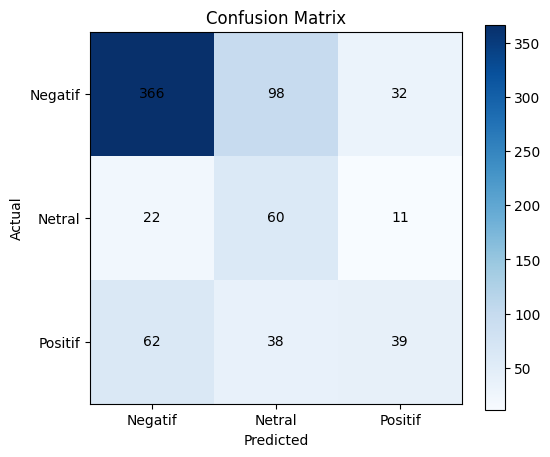

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)

print(f"Akurasi : {acc*100:.2f}%\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(NUM_CLASSES), label_encoder.classes_)
plt.yticks(range(NUM_CLASSES), label_encoder.classes_)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Grafik Training

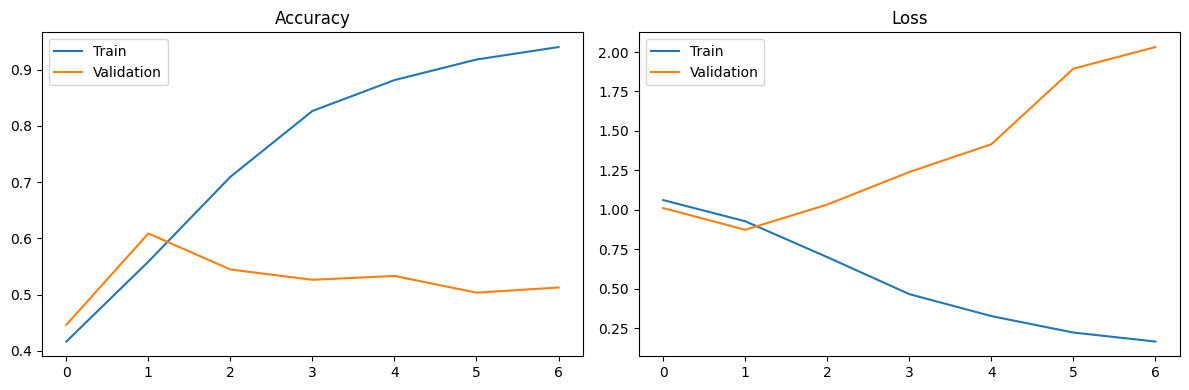

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

simpan model

In [29]:
import pickle

MODEL_PATH = f"{DRIVE_PATH}/model_lstm"

os.makedirs(MODEL_PATH, exist_ok=True)

model.save(f"{MODEL_PATH}/lstm_model.keras")

with open(f"{MODEL_PATH}/tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

with open(f"{MODEL_PATH}/label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

print("Model berhasil disimpan.")

Model berhasil disimpan.
